# Questão 3 - Aplicar Modelos de Machine Learning para prever o preço médio dos carros

In [1]:
# Recarregando o dataset e as bibliotecas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Carregando o dataset e limpando valores repetidos
df = pd.read_csv("precos_carros_brasil.csv", low_memory=False)
df = df.dropna(how='all').drop_duplicates()

In [2]:
# 3.a) Escolher as variáveis numéricas para criar as variáveis independentes do modelo.

# 1. engine_size: Troca a vírgula para ponto e transforma para tipo float
df['engine_size'] = df['engine_size'].astype(str).str.replace(',', '.').str.strip()
df['engine_size'] = pd.to_numeric(df['engine_size'], errors='coerce')

# 2. gear: Fazer label encoding da variável gear
df['gear_encoded'] = df['gear'].map({'manual': 0, 'automatic': 1})

# 3. fuel: One-Hot Encoding
fuel_dummies = pd.get_dummies(df['fuel'], prefix='fuel', drop_first=False)
df = pd.concat([df, fuel_dummies], axis=1)

# 4. brand: Label Encoding de maracas para código númerico
df['brand_encoded'] = df['brand'].astype('category').cat.codes

# Variáveis independentes
features = ['year_of_reference', 'year_model', 'engine_size',
            'gear_encoded', 'brand_encoded',
            'fuel_Gasoline', 'fuel_Alcohol', 'fuel_Diesel']

target = 'avg_price_brl'

# Remove linhas com NaN nas features
df_ml = df[features + [target]].dropna()

# Alocar as features na variável X e o target na variável Y
X = df_ml[features]
y = df_ml[target]

# Dispor as variáveis transformadas
print('=== Variáveis e Transformações ===')
print('\nVariáveis originais transformadas:')
print('  - engine_size  : string com vírgula -> float (ex: "1,6" => 1.6)')
print('  - gear         : Label Encoding -> manual=0, automatic=1')
print('  - fuel         : One-Hot Encoding -> colunas fuel_Gasoline, fuel_Alcohol, fuel_Diesel')
print('  - brand        : Label Encoding -> código inteiro por categoria')
print(f'\nVariáveis independentes (features): {features}')
print(f'Variável target: {target}')
print(f'\nTotal de amostras para modelagem: {len(df_ml):,}')
display(X.head())

=== Variáveis e Transformações ===

Variáveis originais transformadas:
  - engine_size  : string com vírgula -> float (ex: "1,6" => 1.6)
  - gear         : Label Encoding -> manual=0, automatic=1
  - fuel         : One-Hot Encoding -> colunas fuel_Gasoline, fuel_Alcohol, fuel_Diesel
  - brand        : Label Encoding -> código inteiro por categoria

Variáveis independentes (features): ['year_of_reference', 'year_model', 'engine_size', 'gear_encoded', 'brand_encoded', 'fuel_Gasoline', 'fuel_Alcohol', 'fuel_Diesel']
Variável target: avg_price_brl

Total de amostras para modelagem: 202,295


,year_of_reference,year_model,engine_size,gear_encoded,brand_encoded,fuel_Gasoline,fuel_Alcohol,fuel_Diesel
0,2021.0,2002.0,1.0,0,2,True,False,False
1,2021.0,2001.0,1.0,0,2,True,False,False
2,2021.0,2000.0,1.0,0,2,True,False,False
3,2021.0,2000.0,1.0,0,2,False,True,False
4,2021.0,2001.0,1.6,0,2,True,False,False


In [3]:
# 3.b) Criar partições contendo 75 % dos dados para treino e 25% para teste
from sklearn.model_selection import train_test_split

# Separando as variáveis de X e Y em treino e teste para serem aplicadas nos algoritmos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print('=== Partição Treino / Teste ===')
print(f'Total de amostras  : {len(X):,}')
print(f'Treino (75%)       : {len(X_train):,} amostras')
print(f'Teste  (25%)       : {len(X_test):,} amostras')

=== Partição Treino / Teste ===
Total de amostras  : 202,295
Treino (75%)       : 151,721 amostras
Teste  (25%)       : 50,574 amostras


In [4]:
# 3.c) Treinar os modelos RandomForest e XGBoost para predição dos preços dos carros.
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import time

# Random Forest:
print('=== Modelo 1: RandomForestRegressor ===')
print('Parâmetros: n_estimators=200, max_depth=15, min_samples_split=5,')
print('            min_samples_leaf=2, n_jobs=-1, random_state=42')
print()

# Cria os parâmetros do modelo RandomForest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

# Aloca as variáveis de treino dentro do modelo RandomForest e configura o tempo de execução
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time
print(f'Tempo de treinamento: {rf_train_time:.2f} segundos')

# XGBoost:
print('=== Modelo 2: XGBRegressor ===')
print('Parâmetros: n_estimators=300, max_depth=8, learning_rate=0.05,')
print('            subsample=0.8, colsample_bytree=0.8, random_state=42')
print()

# Cria os parâmetros do modelo XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

# Aloca as variáveis de treino dentro do modelo XGBRegressor e configura o tempo de execução
start_time = time.time()
xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time
print(f'Tempo de treinamento: {xgb_train_time:.2f} segundos')

=== Modelo 1: RandomForestRegressor ===
Parâmetros: n_estimators=200, max_depth=15, min_samples_split=5,
            min_samples_leaf=2, n_jobs=-1, random_state=42

Tempo de treinamento: 3.23 segundos
=== Modelo 2: XGBRegressor ===
Parâmetros: n_estimators=300, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42

Tempo de treinamento: 1.19 segundos


In [5]:
# 3.d) Gravar os valores preditos em variáveis criadas
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Criando Dataframe de comparação
df_predicoes = pd.DataFrame({
    'Valor Real (R$)': y_test.values,
    'Predição RF (R$)': y_pred_rf,
    'Predição XGB (R$)': y_pred_xgb
}).reset_index(drop=True)

print("=== Amostra dos Valores Preditos ===")
display(df_predicoes.head(10).style.format('R$ {:,.2f}'))

=== Amostra dos Valores Preditos ===


,Valor Real (R$),Predição RF (R$),Predição XGB (R$)
0,"R$ 42,595.00","R$ 44,811.74","R$ 46,028.29"
1,"R$ 10,989.00","R$ 13,166.64","R$ 12,799.69"
2,"R$ 9,087.00","R$ 15,827.11","R$ 15,669.07"
3,"R$ 26,965.00","R$ 26,223.99","R$ 26,637.41"
4,"R$ 57,102.00","R$ 71,065.93","R$ 68,958.28"
5,"R$ 34,701.00","R$ 50,504.65","R$ 50,766.20"
6,"R$ 40,934.00","R$ 41,649.47","R$ 41,148.16"
7,"R$ 80,120.00","R$ 77,892.95","R$ 77,705.01"
8,"R$ 20,559.00","R$ 27,106.52","R$ 28,032.10"
9,"R$ 104,110.00","R$ 128,243.99","R$ 127,088.37"


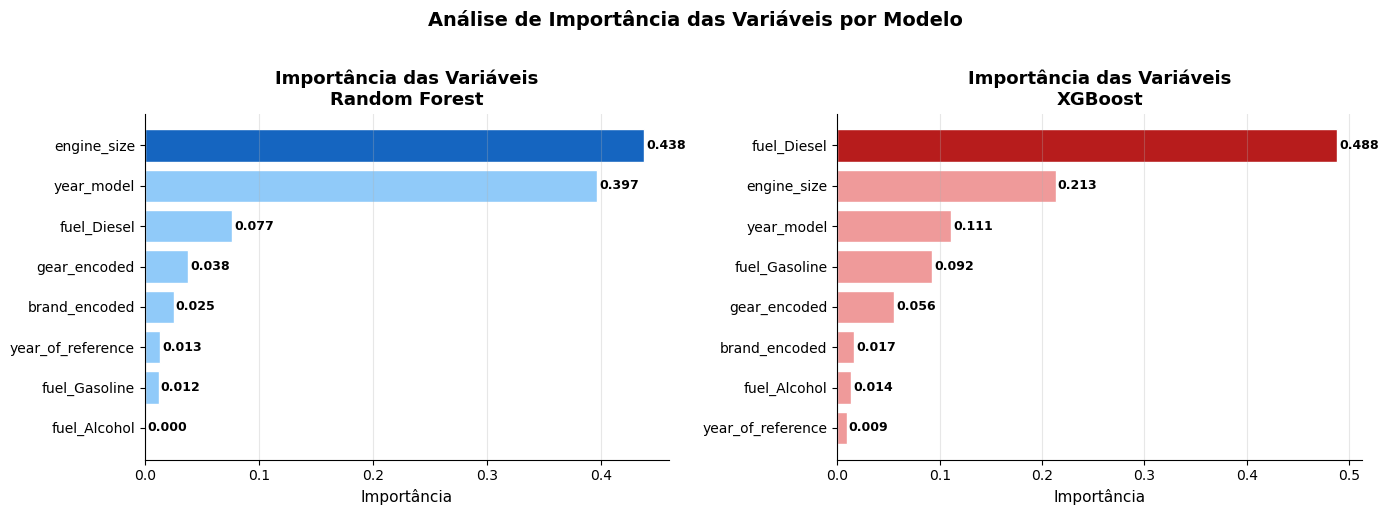


=== Ranking de Importância — Random Forest ===


,Importância
engine_size,0.4378
year_model,0.3968
fuel_Diesel,0.0768
gear_encoded,0.0378
brand_encoded,0.0253
year_of_reference,0.0134
fuel_Gasoline,0.0121
fuel_Alcohol,0.0000



=== Ranking de Importância — XGBoost ===


,Importância
fuel_Diesel,0.4879
engine_size,0.2133
year_model,0.1113
fuel_Gasoline,0.0925
gear_encoded,0.0557
brand_encoded,0.0165
fuel_Alcohol,0.0137
year_of_reference,0.0090


In [6]:
# 3.e) Realizar a análise de importância das variáveis para estimar a variável target
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

feature_names = features
importancia_rf  = pd.Series(rf_model.feature_importances_,  index=feature_names).sort_values(ascending=True)
importancia_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
colors_rf = ['#1565C0' if v == importancia_rf.max() else '#90CAF9' for v in importancia_rf.values]
axes[0].barh(importancia_rf.index, importancia_rf.values, color=colors_rf, edgecolor='white')
for i, v in enumerate(importancia_rf.values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Importância das Variáveis\nRandom Forest', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importância', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
colors_xgb = ['#B71C1C' if v == importancia_xgb.max() else '#EF9A9A' for v in importancia_xgb.values]
axes[1].barh(importancia_xgb.index, importancia_xgb.values, color=colors_xgb, edgecolor='white')
for i, v in enumerate(importancia_xgb.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Importância das Variáveis\nXGBoost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importância', fontsize=11)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Análise de Importância das Variáveis por Modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Ranking de Importância — Random Forest ===')
display(importancia_rf.sort_values(ascending=False).to_frame('Importância').style.format('{:.4f}'))
print('\n=== Ranking de Importância — XGBoost ===')
display(importancia_xgb.sort_values(ascending=False).to_frame('Importância').style.format('{:.4f}'))

**3.f)** No modelo Random Forest, a variável engine_size se destacou como a variável mais importante enquanto que no modelo XGBoost a variável fuel_Diesel se destacou como a mais importante, porém no mesmo modelo a variável engine_size também mostrou uma importância significativa. Enquanto que a variável fuel_Alcohol tem importância quase inexistente nos dois modelos

=== Métricas de Avaliação dos Modelos ===


,MSE,RMSE,MAE,R²
RandomForest,"105,474,479.13","10,270.08","5,614.14",0.9608
XGBoost,"108,384,077.72","10,410.77","5,704.61",0.9597


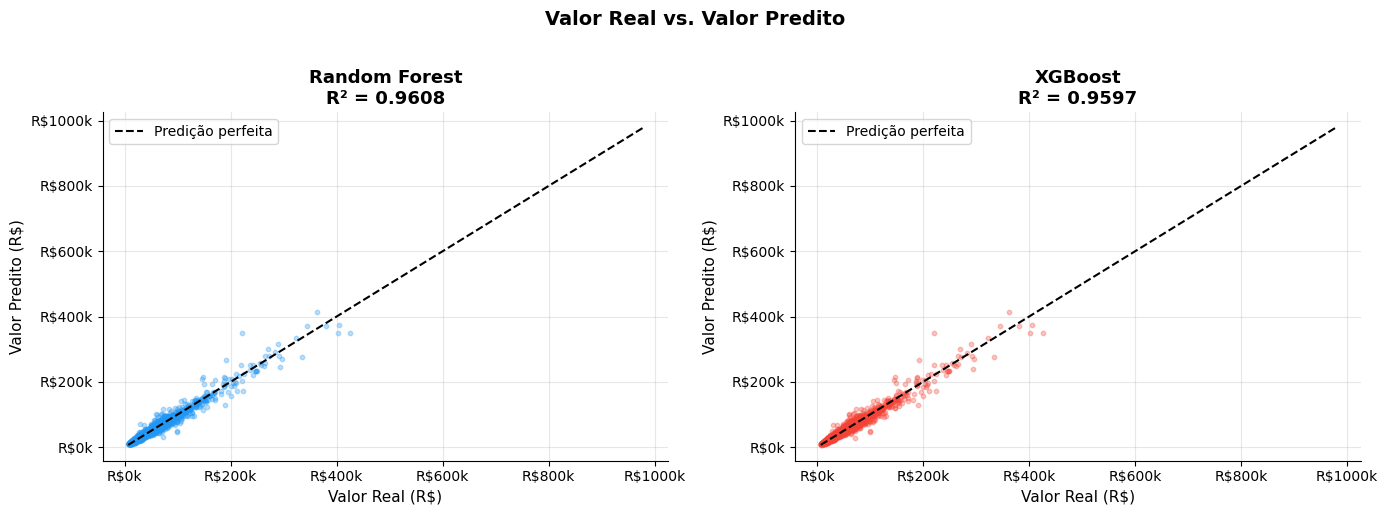

In [7]:
# 3.g) Avaliação dos modelos com MSE, MAE e R²
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Métricas
metricas = {
    'RandomForest': {
        'MSE' : mean_squared_error(y_test, y_pred_rf),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        'MAE' : mean_absolute_error(y_test, y_pred_rf),
        'R²'  : r2_score(y_test, y_pred_rf)
    },
    'XGBoost': {
        'MSE' : mean_squared_error(y_test, y_pred_xgb),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        'MAE' : mean_absolute_error(y_test, y_pred_xgb),
        'R²'  : r2_score(y_test, y_pred_xgb)
    }
}

df_metricas = pd.DataFrame(metricas).T
print('=== Métricas de Avaliação dos Modelos ===')
display(df_metricas.style.format({'MSE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAE': '{:,.2f}', 'R²': '{:.4f}'}) \
        .highlight_max(subset=['R²'], color='#C8E6C9') \
        .highlight_min(subset=['MSE','RMSE','MAE'], color='#C8E6C9'))

# Gráfico: Valor Real vs Predito
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = min(2000, len(y_test))
idx = np.random.choice(len(y_test), sample, replace=False)

for ax, (nome, preds, cor) in zip(axes, [
    ('Random Forest', y_pred_rf[idx], '#2196F3'),
    ('XGBoost',       y_pred_xgb[idx], '#F44336')
]):
    ax.scatter(y_test.values[idx], preds, alpha=0.3, s=10, color=cor)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Predição perfeita')
    r2_val = metricas['RandomForest']['R²'] if 'Forest' in nome else metricas['XGBoost']['R²']
    ax.set_title(f'{nome}\nR² = {r2_val:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Valor Real (R$)', fontsize=11)
    ax.set_ylabel('Valor Predito (R$)', fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
    ax.legend(fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(alpha=0.3)

plt.suptitle('Valor Real vs. Valor Predito', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**3.h)** No caso, o **RandomForest** apresentou o melhor desempenho geral, **R^2** teve maiores valores e tanto **MSE** quanto **MAE** tiveram valores menores que o **XGBoost**.  A métrica **R^2** foi decisiva na escolha, pois mede a proporção da variância do preço explicada pelo modelo.